(↓のセルいる？)

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [1]:
from quri_parts.core.estimator.gradient import (
    create_numerical_gradient_estimator,
)
from quri_parts.qulacs.estimator import (
    create_qulacs_vector_concurrent_parametric_estimator,
)
from quri_parts.algo.optimizer import Adam

In [2]:
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from quri_parts.circuit.utils.circuit_drawer import draw_circuit

iris = datasets.load_iris()
print(iris.feature_names)
df = pd.DataFrame(iris.data, columns=iris.feature_names)
print(df)
x = df.loc[:, ["petal length (cm)", "petal width (cm)"]]
x_train, x_test, y_train, y_test = train_test_split(x, iris.target, test_size=0.25, random_state=0)
x_train = x_train.to_numpy()

n_qubits = 5
num_class = 3

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1

In [3]:
from scikit_quri.circuit import create_qcl_ansatz

circuit = create_qcl_ansatz(n_qubits, 3, 1.0)
draw_circuit(circuit.circuit)
circuit.circuit.parameter_count

   ___     ___     ___     ___     ___     ___     ___     ___     ___     ___  
  |PRY|   |PRZ|   |Mat|   |PRX|   |PRZ|   |PRX|   |Mat|   |PRX|   |PRZ|   |PRX| 
--|0  |---|1  |---|10 |---|11 |---|12 |---|13 |---|26 |---|27 |---|28 |---|29 |-
  |___|   |___|   |   |   |___|   |___|   |___|   |   |   |___|   |___|   |___| 
   ___     ___    |   |    ___     ___     ___    |   |    ___     ___     ___  
  |PRY|   |PRZ|   |   |   |PRX|   |PRZ|   |PRX|   |   |   |PRX|   |PRZ|   |PRX| 
--|2  |---|3  |---|   |---|14 |---|15 |---|16 |---|   |---|30 |---|31 |---|32 |-
  |___|   |___|   |   |   |___|   |___|   |___|   |   |   |___|   |___|   |___| 
   ___     ___    |   |    ___     ___     ___    |   |    ___     ___     ___  
  |PRY|   |PRZ|   |   |   |PRX|   |PRZ|   |PRX|   |   |   |PRX|   |PRZ|   |PRX| 
--|4  |---|5  |---|   |---|17 |---|18 |---|19 |---|   |---|33 |---|34 |---|35 |-
  |___|   |___|   |   |   |___|   |___|   |___|   |   |   |___|   |___|   |___| 
   ___     ___    |   |    _

55

In [4]:
from scikit_quri.qnn.classifier import QNNClassifier
from scikit_quri.backend import SimEstimator

adam = Adam()
estimator = SimEstimator()
gradient_estimator = create_numerical_gradient_estimator(
    create_qulacs_vector_concurrent_parametric_estimator(), delta=1e-10
)
qnn = QNNClassifier(circuit, num_class, estimator, gradient_estimator, optimizer=adam)

In [5]:
qnn.fit(x_train, y_train, maxiter=50)

 iter:49/50 cost:optimizer_state.cost=0.38269791129513236


In [6]:
import numpy as np
np.eye(3)[iris.target]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

In [7]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

[[0.0686255  0.18183892 0.74953558]
 [0.11127419 0.70014858 0.18857723]
 [0.81965007 0.09841073 0.0819392 ]
 [0.11163158 0.16806397 0.72030446]
 [0.80971798 0.10122141 0.08906061]
 [0.06100071 0.11025414 0.82874514]
 [0.79904761 0.12166805 0.07928433]
 [0.10786999 0.5433856  0.34874441]
 [0.10545272 0.56067834 0.33386894]
 [0.11357632 0.64866373 0.23775995]
 [0.11380925 0.40651381 0.47967695]
 [0.10986223 0.56461396 0.3255238 ]
 [0.10246307 0.62327123 0.27426569]
 [0.10874727 0.55467175 0.33658098]
 [0.10584059 0.57330724 0.32085217]
 [0.75865915 0.12247335 0.1188675 ]
 [0.10986223 0.56461396 0.3255238 ]
 [0.10439253 0.65096072 0.24464675]
 [0.80126152 0.11833339 0.08040509]
 [0.76799848 0.14771354 0.08428797]
 [0.10024024 0.32738393 0.57237583]
 [0.10986223 0.56461396 0.3255238 ]
 [0.72159333 0.14046353 0.13794314]
 [0.81965007 0.09841073 0.0819392 ]
 [0.10872976 0.42191125 0.46935899]
 [0.68662712 0.17422021 0.13915268]
 [0.6625662  0.215916   0.1215178 ]
 [0.10761603 0.63536069 0.25

/Users/hayatoyunoki/Desktop/QML/tutorial/scikit-quri/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


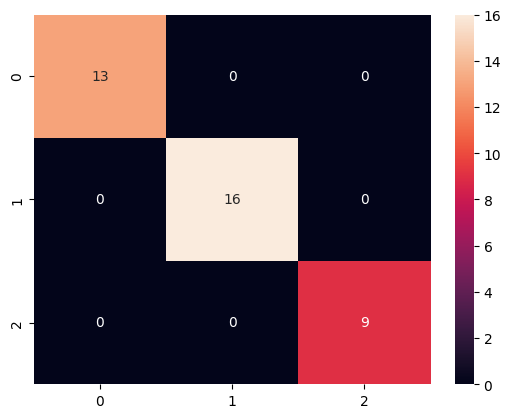

In [8]:
from scipy.special import softmax
from sklearn.metrics import log_loss, confusion_matrix
import seaborn as sns

y_pred = qnn.predict(x_test)
y_pred_sm = softmax(y_pred, axis=1)
print(y_pred_sm)
print(y_test)

log = log_loss(y_test, y_pred_sm)
cm = confusion_matrix(y_test, y_pred.argmax(axis=1))
sns.heatmap(cm, annot=True)
print(log)